In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Load dataset
df = pd.read_csv("../data/heart_disease_data.csv")
total_missing = df.isna().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


In [12]:
X = df.drop(columns=["target"])
y = df["target"].values

In [13]:
# Process dataset
cat_cols = ["cp", "restecg", "slope", "thal"]
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
binary_cols = ["sex", "fbs", "exang"]
feature_names = list(X.columns)

# OneHotEncoding for categorical attributes
encoder = OneHotEncoder(sparse_output=False)
X_cat_ohe = encoder.fit_transform(X[cat_cols])

# StandardScaler for numerical attributes
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_cols])

# Binary attributes
X_binary = X[binary_cols].values  

X_processed = np.hstack([X_cat_ohe, X_num_scaled, X_binary])
print("X shape before Processing:", X.shape)
print("X shape after Processing:", X_processed.shape)
print("First Row:\n", X_processed[0])

X shape before Processing: (606, 13)
X shape after Processing: (606, 23)
First Row:
 [ 1.          0.          0.          0.          1.          0.
  0.          0.          0.          1.          0.          0.
  0.          1.         -0.7021358  -0.09273778  0.18815239  0.01544279
 -0.89686172  1.24459328  1.          1.          1.        ]


In [14]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Train RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9672131147540983

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        56
           1       0.97      0.97      0.97        66

    accuracy                           0.97       122
   macro avg       0.97      0.97      0.97       122
weighted avg       0.97      0.97      0.97       122




Feature Importances
      feature  importance
3       thal      0.2010
0         cp      0.1361
7    thalach      0.0944
8    oldpeak      0.0902
9         ca      0.0842
4        age      0.0753
6       chol      0.0753
2      slope      0.0733
5   trestbps      0.0665
12     exang      0.0398
1    restecg      0.0297
10       sex      0.0263
11       fbs      0.0079


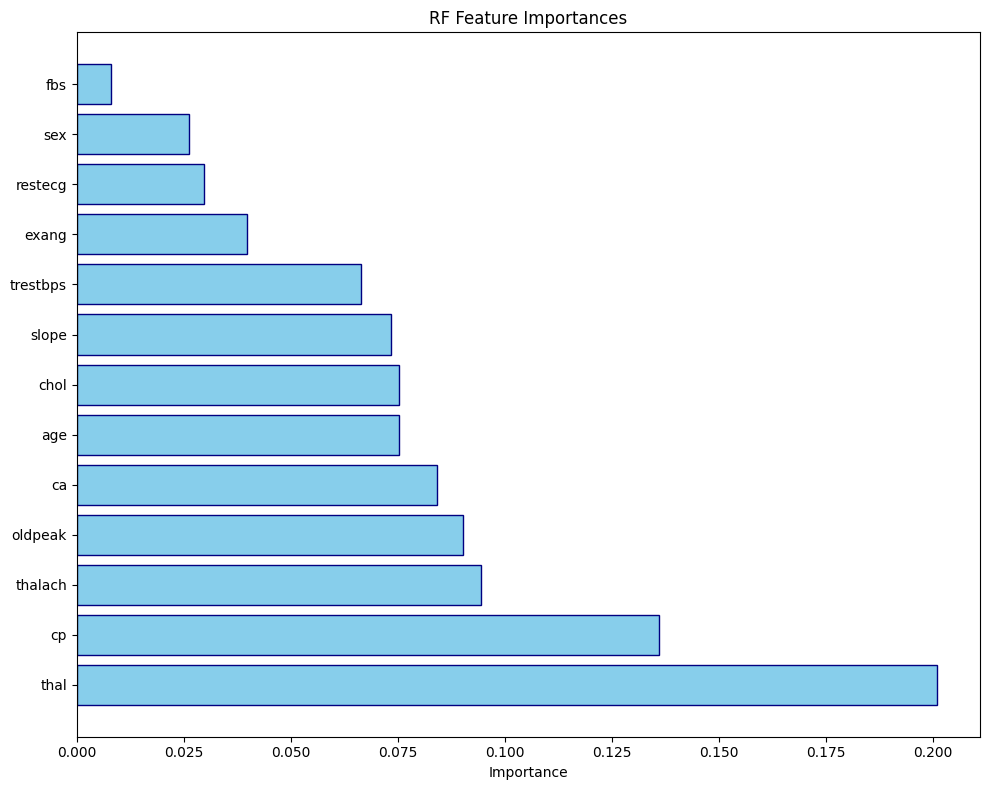

In [17]:
# Compute and plot feature importances
importances = rf.feature_importances_
cat_end_idx = X_cat_ohe.shape[1]
num_end_idx = cat_end_idx + len(num_cols)
binary_start_idx = num_end_idx

# Combine one hot encoded categorical attributes
grouped_importances = {}
for i, group in enumerate(cat_cols):
    start = sum(len(encoder.categories_[j]) for j in range(i))
    end = start + len(encoder.categories_[i])
    grouped_importances[group] = np.sum(importances[start:end])

# Numerical attributes
for i, name in enumerate(num_cols):
    grouped_importances[name] = importances[cat_end_idx + i]
    
# Binary attributes
for i, name in enumerate(binary_cols):
    grouped_importances[name] = importances[num_end_idx + i]

imp_df = pd.DataFrame(list(grouped_importances.items()), 
                      columns=['feature', 'importance']).sort_values('importance', ascending=False)

print("\nFeature Importances\n", imp_df.round(4))

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], color='skyblue', edgecolor='navy')
plt.xlabel('Importance')
plt.title('RF Feature Importances')
plt.tight_layout()
plt.show()
